In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from openpiv import pyprocess, validation, filters, piv
import scipy.signal
from scipy import ndimage
from scipy import ndimage as ndi
from matplotlib.animation import FuncAnimation, writers
from matplotlib.animation import PillowWriter
from pathlib import Path

In [2]:
# Test it by making another gif from the .nc files, using ~/Box for Hanna-Brian generality
# Since they have no time dimension, we need a trick to open them as a mfdataset

import glob
import os

# Expand the tilde to the home directory
pattern = os.path.expanduser('~/Box/GWaves_2023_10_11-14_SEPAC/VIS/Data/VIS_2023_10_13*')

# Get list of files
files = sorted(glob.glob(pattern))

# Open each file and add a new 'time' coordinate
datasets = [xr.open_dataset(f).assign_coords(time=i) for i, f in enumerate(files)]

# Concatenate along the new 'time' dimension
ds = xr.concat(datasets, dim='time')

ds

<xarray.Dataset> Size: 95MB
Dimensions:    (time: 14, latitude: 1125, longitude: 1500)
Coordinates:
  * latitude   (latitude) float32 4kB 9.94 9.9 9.86 ... -34.94 -34.98 -35.02
  * longitude  (longitude) float32 6kB -129.9 -129.9 -129.9 ... -70.02 -69.98
  * time       (time) int64 112B 0 1 2 3 4 5 6 7 8 9 10 11 12 13
Data variables:
    Rad        (time, latitude, longitude) float32 94MB nan nan ... 66.74 78.8
Attributes: (12/29)
    naming_authority:          gov.nesdis.noaa
    Conventions:               CF-1.7
    standard_name_vocabulary:  CF Standard Name Table (v35, 20 July 2016)
    institution:               DOC/NOAA/NESDIS > U.S. Department of Commerce,...
    project:                   GOES
    production_site:           RBU
    ...                        ...
    date_created:              2023-10-13T14:29:56.1Z
    time_coverage_start:       2023-10-13T14:20:20.9Z
    time_coverage_end:         2023-10-13T14:29:51.8Z
    LUT_Filenames:             SpaceLookParams(FM1A_ADR1270_PR_12_02_01)-7371...
    id:                        68a174cb-b605-43e5-bff6-26cecb9c53c8
    history:                   2024-10-26 06:33:38: Resampled to regular lat-...

In [3]:
#dataset1 = xr.open_dataset('/Users/hannachaja/Documents/Research/PIV/synthetic/creations/BIT_DB0/B9_DB0_P15_A100_W400_P15_A150_W750_IR_2waves_halfhour0.nc') 
#dataset2 = xr.open_dataset('/Users/hannachaja/Documents/Research/PIV/synthetic/creations/BIT_DB0/B9_DB0_P15_A100_W400_P15_A150_W750_IR_2waves_halfhour1.nc') 
#dataset1 = xr.open_dataset('/Users/hannachaja/Documents/Research/PIV/synthetic/creations/BIT_DB0/B9_DB0_P15_A100_W400_D230_P15_A150_W750_D330_IR_2waves_halfhour5.nc')
#dataset2 = xr.open_dataset('/Users/hannachaja/Documents/Research/PIV/synthetic/creations/BIT_DB0/B9_DB0_P15_A100_W400_D230_P15_A150_W750_D330_IR_2waves_halfhour6.nc') 

#dataset1 = xr.open_dataset('/Users/hannachaja/Documents/Research/PIV/synthetic/creations/RAW/case1_RAW_halfhour0.nc') 
#dataset2 = xr.open_dataset('/Users/hannachaja/Documents/Research/PIV/synthetic/creations/RAW/case1_RAW_halfhour1.nc') 

###### BOX FOLDER #############
dataset1 = xr.open_dataset('~/Box/GWaves_2023_10_11-14_SEPAC/IR/Data/IR_2023_10_12_03_15.nc')
dataset2 = xr.open_dataset('~/Box/GWaves_2023_10_11-14_SEPAC/IR/Data/IR_2023_10_12_03_45.nc')

In [4]:
dataarray1 = dataset1.to_array().squeeze()
dataarray2 = dataset2.to_array().squeeze()

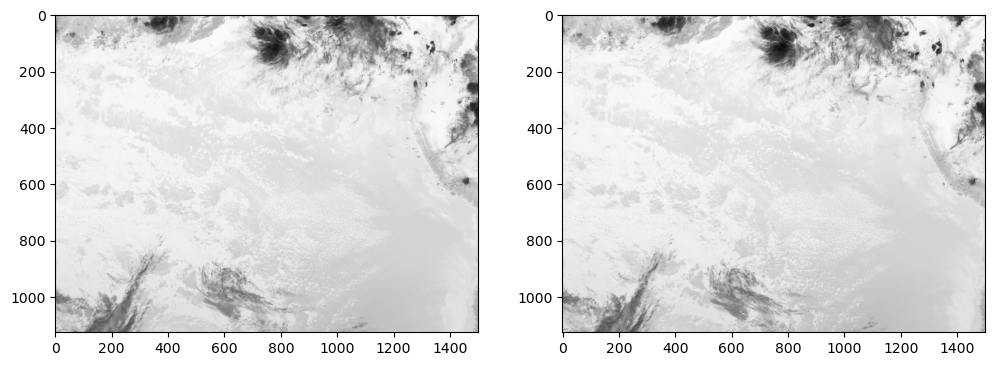

In [5]:
fig,ax = plt.subplots(1,2,figsize=(12,10))
ax[0].imshow(dataarray1,cmap=plt.cm.gray);
ax[1].imshow(dataarray2,cmap=plt.cm.gray);

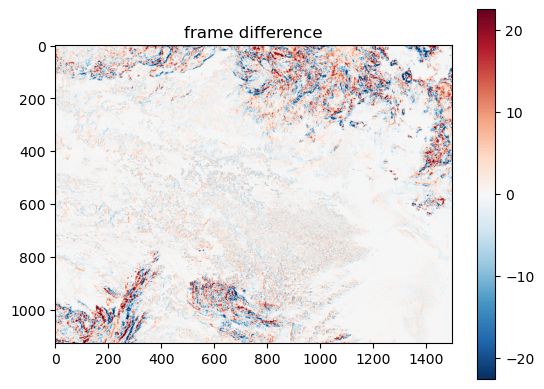

In [6]:
diff = dataarray2 - dataarray1
plt.imshow(diff, cmap="RdBu_r",
           vmin=-np.nanpercentile(np.abs(diff),99),
           vmax= np.nanpercentile(np.abs(diff),99))
plt.colorbar()
plt.title("frame difference")
plt.show()

IR_2023_10_12_00_15
Allen


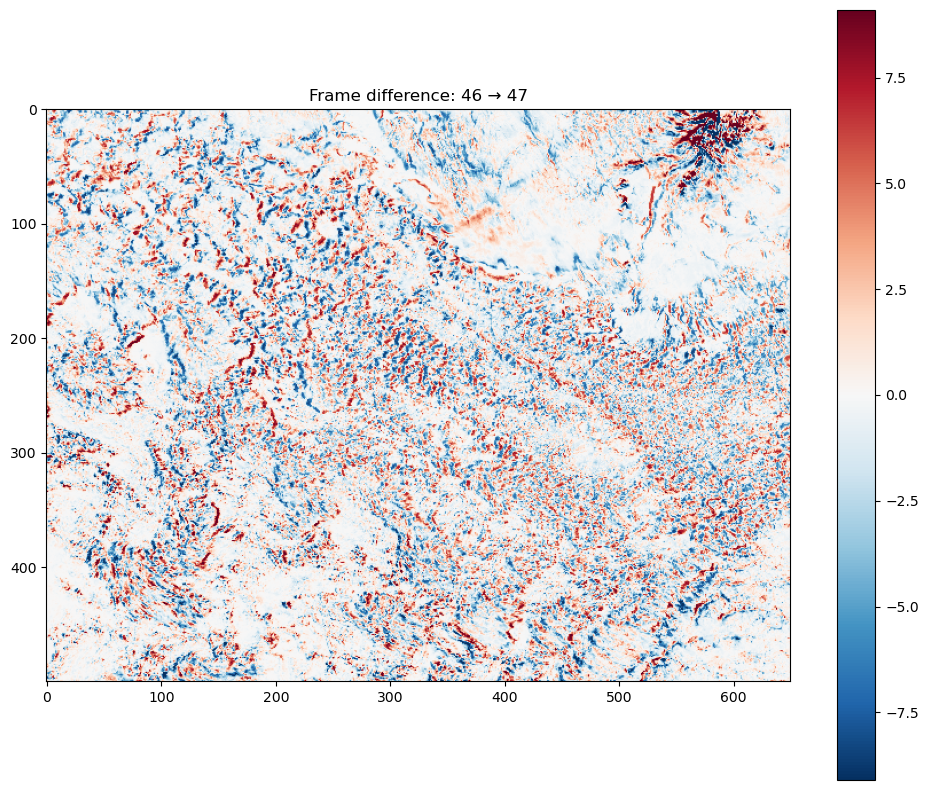

In [7]:
# -----------------------------
# Pick your files
# -----------------------------
files = sorted(glob.glob(os.path.expanduser(
    '/Users/hannachaja/Documents/Research/PIV/synthetic/creations/Allen/IR_2023_10_12*.nc'
)))

filetag   = Path(files[0]).name.split('_IR_')[0] if '_IR_' in Path(files[0]).name else Path(files[0]).stem
foldertag = Path(files[0]).parent.name

print(filetag)
print(foldertag)

def process_file(path_a):
    ds1 = xr.open_dataset(path_a)
    da1 = ds1.to_array().squeeze()

    y0, y1 = 400, 900
    x0, x1 = 450, 1100

    # crop by positional index along latitude, longitude
    da1 = da1.isel(latitude=slice(y0, y1), longitude=slice(x0, x1))
    return da1.values   # return numpy array

sat_stack = np.stack([process_file(f) for f in files], axis=0)
diff_stack = sat_stack[1:] - sat_stack[:-1]

vmax = np.nanpercentile(np.abs(diff_stack), 99)
vmin = -vmax

# -----------------------------
# Plot first diff frame
# -----------------------------
fig, ax = plt.subplots(figsize=(12,10))

im = ax.imshow(diff_stack[0], cmap='RdBu_r', vmin=vmin, vmax=vmax)
cb = plt.colorbar(im, ax=ax)
ax.set_title('Frame difference: 0 → 1')

def update(i):
    im.set_data(diff_stack[i])
    ax.set_title(f'Frame difference: {i} → {i+1}')
    return [im]

anim = FuncAnimation(
    fig,
    update,
    frames=diff_stack.shape[0],
    interval=150,
    blit=True
)

outdir = "/Users/hannachaja/Documents/Research/PIV/synthetic/creations/" + str(foldertag) + "/"
os.makedirs(outdir, exist_ok=True)

outfile = os.path.join(outdir, "frame_difference_" + str(filetag) + ".gif")
anim.save(outfile, writer=PillowWriter(fps=6), dpi=120)

In [8]:
smoothed_image = ndimage.gaussian_filter(dataarray1, sigma=8) ########## USE 12 for synthetic
smoothed_image2 = ndimage.gaussian_filter(dataarray2, sigma=8)

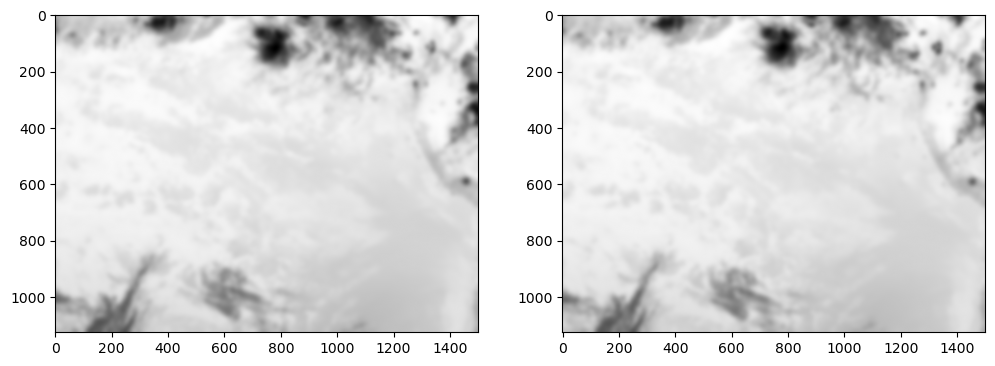

In [9]:
fig,ax = plt.subplots(1,2,figsize=(12,10))
ax[0].imshow(smoothed_image,cmap=plt.cm.gray);
ax[1].imshow(smoothed_image2,cmap=plt.cm.gray);

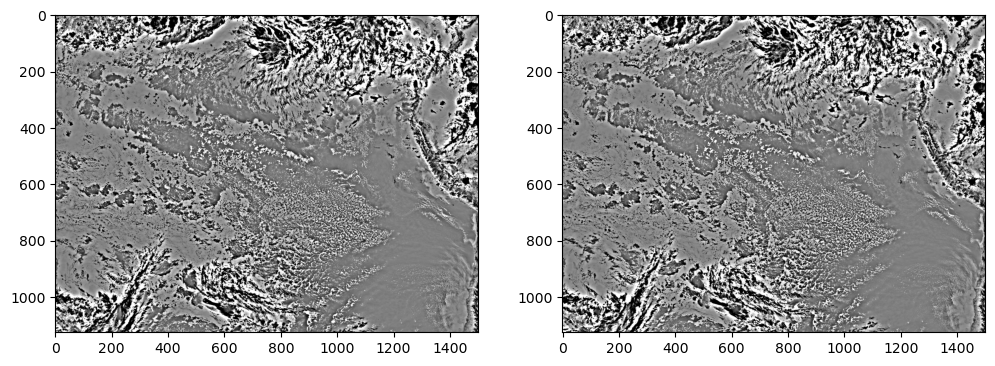

In [10]:
img1 = dataarray1-smoothed_image
img2 = dataarray2-smoothed_image2

fig,ax = plt.subplots(1,2,figsize=(12,10))
ax[0].imshow(img1,cmap=plt.cm.gray, vmin=-5, vmax=5);
ax[1].imshow(img2,cmap=plt.cm.gray, vmin=-5, vmax=5); 


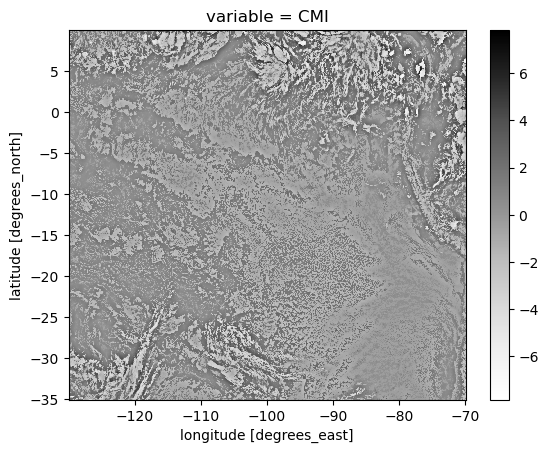

In [11]:
i1 = np.sqrt(np.abs(img1))*np.sign(img1)
i2 = np.sqrt(np.abs(img2))*np.sign(img2)
i2.plot(cmap='Greys')

In [12]:
hp1 = xr.DataArray(i1, coords=dataarray1.coords, dims=dataarray1.dims, name='Rad_hp')
hp2 = xr.DataArray(i2, coords=dataarray2.coords, dims=dataarray2.dims, name='Rad_hp')

In [13]:
frame_a = hp1.values.astype(np.float32)
frame_b = hp2.values.astype(np.float32)

In [14]:
window_size = 32   #was 32
search_size = 32   # was 32
overlap =  18  #was 18
dt = 1  # By having dt=1, units are pixels per frame, not seconds


In [15]:
# diff = frame_b.astype(np.float32) - frame_a.astype(np.float32)
# diff_mag = np.abs(diff)

# # smooth a little so this reflects coherent change, not pixel noise
# diff_s = ndimage.gaussian_filter(diff_mag, sigma=4)

# local RMS / activity map
#activity = np.sqrt(ndimage.uniform_filter(diff_s**2, size=41))

In [16]:
# u, v, sig2noise = pyprocess.extended_search_area_piv(
#     frame_a.astype(np.float32),
#     frame_b.astype(np.float32),
#     window_size=window_size,
#     overlap=overlap,
#     dt=dt,
#     search_area_size=search_size,
#     sig2noise_method='peak2peak'
# )

In [17]:
# invalid_mask = validation.sig2noise_val(u, v,
#     sig2noise,
#     threshold = 1.05,       ################# USE 1.05 for synthetic ##############################
# )


# x, y = pyprocess.get_coordinates(
#     image_size=frame_a.shape,
#     search_area_size=search_size,
#     overlap=overlap
# )

# activity_piv = np.full_like(u, np.nan, dtype=float)

# half = window_size // 2
# for j in range(y.shape[0]):
#     for i in range(x.shape[1]):
#         cx = int(x[j, i])
#         cy = int(y[j, i])

#         x0 = max(cx - half, 0)
#         x1 = min(cx + half + 1, diff_s.shape[1])
#         y0 = max(cy - half, 0)
#         y1 = min(cy + half + 1, diff_s.shape[0])

#         patch = diff_s[y0:y1, x0:x1]
#         activity_piv[j, i] = np.nanmean(patch)

# # choose a threshold
# activity_thresh = np.nanpercentile(activity_piv, 40)
# low_activity_mask = activity_piv < activity_thresh

# # ---------------------------------------------------
# # NEW: combine masks HERE
# # this is the key insertion point
# # ---------------------------------------------------
# #invalid_mask = invalid_mask | low_activity_mask
# invalid = np.logical_or(invalid_mask, low_activity_mask)

# u3, v3, _ = filters.replace_outliers(
#     u, v, invalid,
#     method='localmean',
#     max_iter=3,
#     kernel_size=5,
# )

# plt.pcolormesh(u3, vmin=-10, vmax=10)
# plt.gca().invert_yaxis() 
# plt.colorbar(label="u3")

/Users/hannachaja/Applications/anaconda3/envs/stratocu_waves/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/hannachaja/Applications/anaconda3/envs/stratocu_waves/lib/python3.13/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


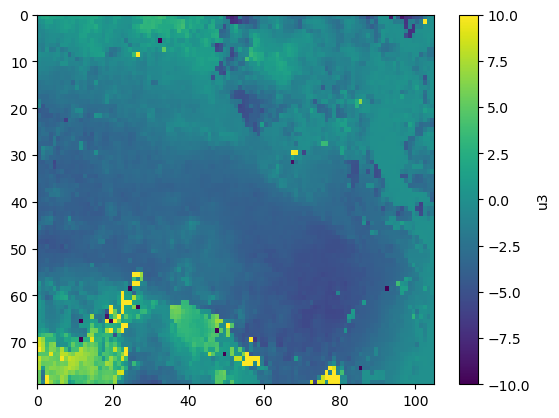

NaNs in frame_a: 0
NaNs in frame_b: 0
NaNs in activity_img: 0


In [18]:
diff = frame_b.astype(np.float32) - frame_a.astype(np.float32)
activity_img = ndimage.gaussian_filter(np.abs(diff), sigma=4)

u, v, sig2noise = pyprocess.extended_search_area_piv(
    frame_a.astype(np.float32),
    frame_b.astype(np.float32),
    window_size=window_size,
    overlap=overlap,
    dt=dt,
    search_area_size=search_size,
    sig2noise_method='peak2peak'
)

invalid_mask_snr = validation.sig2noise_val(
    u, v,
    sig2noise,
    threshold=1.05,
)

x, y = pyprocess.get_coordinates(
    image_size=frame_a.shape,
    search_area_size=search_size,
    overlap=overlap
)

activity_piv = np.full_like(u, np.nan, dtype=float)
half = window_size // 2

for j in range(u.shape[0]):
    for i in range(u.shape[1]):
        cx = int(x[j, i])
        cy = int(y[j, i])

        x0 = max(cx - half, 0)
        x1 = min(cx + half + 1, activity_img.shape[1])
        y0 = max(cy - half, 0)
        y1 = min(cy + half + 1, activity_img.shape[0])

        patch = activity_img[y0:y1, x0:x1]
        if patch.size > 0:
            activity_piv[j, i] = np.nanmean(patch)

snr_norm = np.clip((sig2noise - 1.05) / (1.5 - 1.05), 0, 1)

act_scale = np.nanpercentile(activity_piv[np.isfinite(activity_piv)], 95)
act_norm = activity_piv / act_scale
act_norm = np.clip(act_norm, 0, 1)
act_norm[~np.isfinite(act_norm)] = 0

confidence = 0.7 * snr_norm + 0.3 * act_norm
invalid = confidence < 0.35
invalid = np.logical_or(invalid, invalid_mask_snr)

u3, v3, _ = filters.replace_outliers(
    u, v, invalid,
    method='localmean',
    max_iter=3,
    kernel_size=5,
)

plt.pcolormesh(u3, vmin=-10, vmax=10)
plt.gca().invert_yaxis()
plt.colorbar(label="u3")
plt.show()

print("NaNs in frame_a:", np.isnan(frame_a).sum())
print("NaNs in frame_b:", np.isnan(frame_b).sum())
print("NaNs in activity_img:", np.isnan(activity_img).sum())

shape: (79, 105) dtype: float64
min/max: -0.007258866003888939 0.008259680105580224
p50/p90/p95/p99: [2.04373317e-05 5.37332961e-04 9.25639412e-04 2.15885852e-03]
nan count: 0
div p50/p90/p95/p99: [2.04373317e-05 5.37332961e-04 9.25639412e-04 2.15885852e-03]


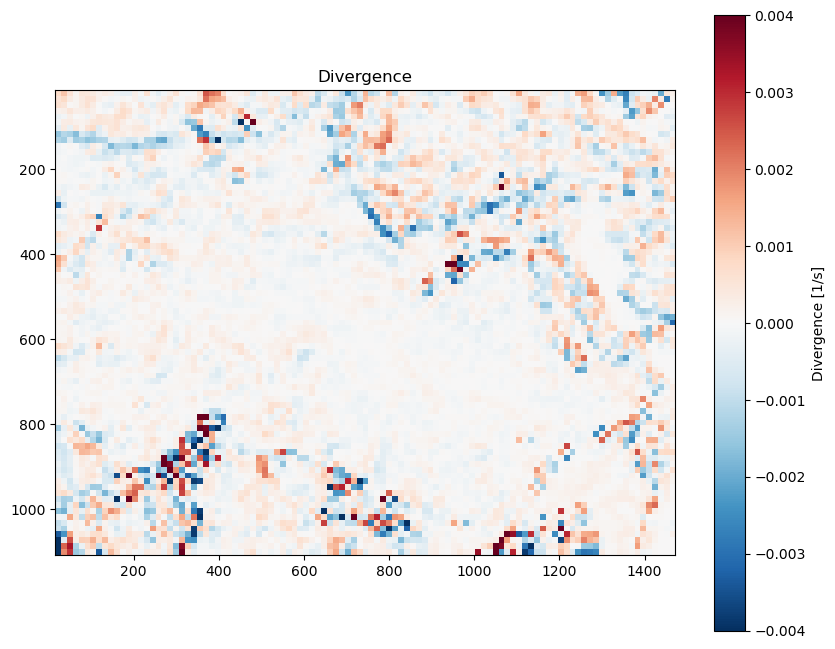

In [19]:
from matplotlib.colors import TwoSlopeNorm
from matplotlib.colors import SymLogNorm
dx_m = 4342.0   # m/px  
dy_m = 4447.0   # m/px  

# real dt between the two frames (seconds)
dt_sec = 1800 #sec

# convert px/frame -> m/s
u_ms = u3 * dx_m / dt_sec
v_ms = v3 * dy_m / dt_sec


div = np.gradient(u_ms, dy_m, dx_m)[1] + np.gradient(v_ms, dy_m, dx_m)[0]   # s^-1 (u,v in m/s; dx,dy in m)

A = div  # or div_stack[i]

print("shape:", A.shape, "dtype:", A.dtype)
print("min/max:", np.nanmin(A), np.nanmax(A))
print("p50/p90/p95/p99:", np.nanpercentile(A, [50,90,95,99]))
print("nan count:", np.isnan(A).sum())

vmax = np.nanpercentile(np.abs(div), 99.5)   # 99–99.7 are typical
norm = TwoSlopeNorm(vcenter=0.0, vmin=-vmax, vmax=vmax)

# Coordinates of PIV grid in pixel units
x_px, y_px = pyprocess.get_coordinates(img1.shape, window_size, overlap, search_size)
extent = [x_px.min(), x_px.max(), y_px.max(), y_px.min()]   # origin='upper'

plt.figure(figsize=(10,8))
plt.imshow(div, origin='upper', cmap='RdBu_r', norm=norm, extent=extent)
plt.colorbar(label='Divergence [1/s]')
plt.title("Divergence")
print("div p50/p90/p95/p99:", np.nanpercentile(div, [50,90,95, 99]))

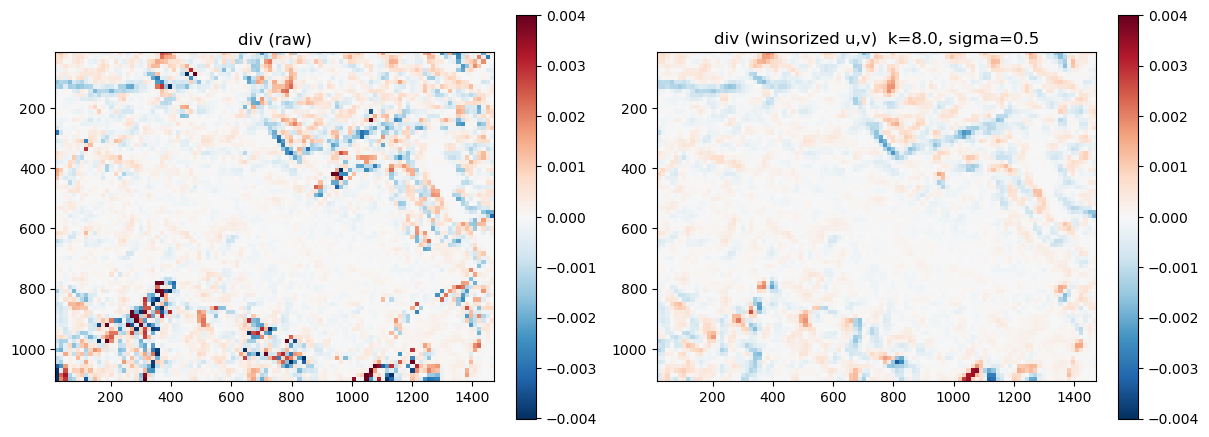

shape: (79, 105) dtype: float64
min/max: -0.003358747244975391 0.0035669935128331493
p50/p90/p95/p99: [1.67555927e-05 3.46996765e-04 5.30767856e-04 1.09194489e-03]
nan count: 0


In [20]:
from scipy.ndimage import median_filter, gaussian_filter
# --- Robust "soft" outlier control on velocities (no discontinuous replacement) ---
u_in = u_ms.copy()
v_in = v_ms.copy()

u_med = median_filter(u_in, size=3, mode="nearest")
v_med = median_filter(v_in, size=3, mode="nearest")

ru = u_in - u_med
rv = v_in - v_med

mad_u = np.nanmedian(np.abs(ru - np.nanmedian(ru))); mad_u = mad_u if mad_u > 0 else 1e-12
mad_v = np.nanmedian(np.abs(rv - np.nanmedian(rv))); mad_v = mad_v if mad_v > 0 else 1e-12

k = 8.0     # try 6–12 (smaller = stronger clipping)
sigma = 0.5 # try 0, 0.3, 0.5, 0.7

# Winsorize residuals toward local median (continuous)
u_fix = u_med + np.clip(ru, -k*mad_u, k*mad_u)
v_fix = v_med + np.clip(rv, -k*mad_v, k*mad_v)

# Optional light smoothing before derivatives
if sigma and sigma > 0:
    u_fix = gaussian_filter(u_fix, sigma=sigma, mode="nearest")
    v_fix = gaussian_filter(v_fix, sigma=sigma, mode="nearest")

# Recompute divergence
div_raw = div.copy()
div_clip = np.gradient(u_fix, dy_m, dx_m)[1] + np.gradient(v_fix, dy_m, dx_m)[0]

# Plot comparison with same normalization (based on raw)
vmax = np.nanpercentile(np.abs(div_raw[np.isfinite(div_raw)]), 99.5)
norm = TwoSlopeNorm(vcenter=0.0, vmin=-vmax, vmax=vmax)

fig, ax = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
im0 = ax[0].imshow(div_raw, origin="upper", cmap="RdBu_r", norm=norm, extent=extent)
ax[0].set_title("div (raw)")
plt.colorbar(im0, ax=ax[0], fraction=0.046)

im1 = ax[1].imshow(div_clip, origin="upper", cmap="RdBu_r", norm=norm, extent=extent)
ax[1].set_title(f"div (winsorized u,v)  k={k}, sigma={sigma}")
plt.colorbar(im1, ax=ax[1], fraction=0.046)

plt.show()

# If you want to keep it downstream:
div = div_clip
A = div
print("shape:", A.shape, "dtype:", A.dtype)
print("min/max:", np.nanmin(A), np.nanmax(A))
print("p50/p90/p95/p99:", np.nanpercentile(A, [50,90,95,99]))
print("nan count:", np.isnan(A).sum())

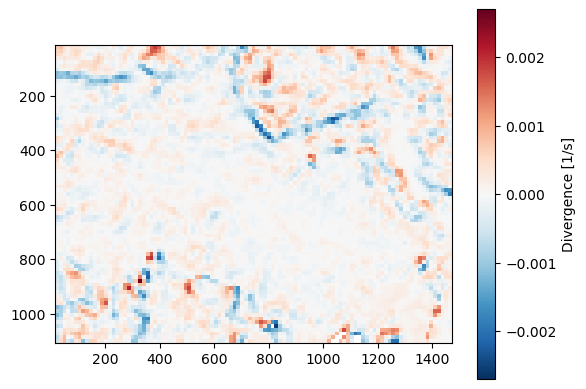

In [21]:
clip = 0.0027
div_masked = np.ma.masked_where(np.abs(div) > clip, div)

plt.imshow(div_masked, origin='upper', cmap='RdBu_r', vmin=-clip, vmax=clip, extent=extent)
plt.colorbar(label='Divergence [1/s]')